In [13]:
import pandas as pd

tpm_path = "../data/tcga/TcgaTargetGtex_rsem_gene_tpm.gz"
pheno_path = "../data/tcga/TcgaTargetGTEX_phenotype.txt"
mitosis_path = "../data/mitosis/mitosis_ensembl_ids.txt"
fetal_path = "../data/fetal/fetal_mitotic_tpm.tsv"

In [14]:
pheno = pd.read_csv(pheno_path, sep="\t", encoding='latin1')

print(pheno.shape)
print(pheno.columns.tolist())
pheno.head()

(19131, 7)
['sample', 'detailed_category', 'primary disease or tissue', '_primary_site', '_sample_type', '_gender', '_study']


,sample,detailed_category,primary disease or tissue,_primary_site,_sample_type,_gender,_study
0,TCGA-V4-A9EE-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
1,TCGA-VD-AA8N-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
2,TCGA-V4-A9EI-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
3,TCGA-VD-AA8O-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
4,TCGA-WC-A888-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA


In [15]:
# Filter to primary tumors
tumor_samples = pheno[pheno["_sample_type"] == "Primary Tumor"]["sample"].tolist()

print(f"Number of tumor samples: {len(tumor_samples)}")
print(tumor_samples[:5])

Number of tumor samples: 9185
['TCGA-V4-A9EE-01', 'TCGA-VD-AA8N-01', 'TCGA-V4-A9EI-01', 'TCGA-VD-AA8O-01', 'TCGA-WC-A888-01']


In [16]:
mitotic_genes = pd.read_csv(mitosis_path, header=None)[0]
mitotic_genes = mitotic_genes.astype(str).str.split(".").str[0]

print(f"Mitotic genes: {len(mitotic_genes)}")
print(mitotic_genes[:5])

Mitotic genes: 662
0    ENSG00000215114
1    ENSG00000167553
2    ENSG00000172273
3    ENSG00000111206
4    ENSG00000109805
Name: 0, dtype: object


In [17]:
chunks = []
chunk_size = 2000

for i, chunk in enumerate(
    pd.read_csv(
        tpm_path,
        sep="\t",
        compression="gzip",
        chunksize=chunk_size,
        index_col=0
    )
):
    # remove Ensembl version suffix if present
    chunk.index = chunk.index.astype(str).str.split(".").str[0]

    # keep only mitotic genes
    chunk = chunk[chunk.index.isin(mitotic_genes)]

    if not chunk.empty:
        # keep only primary tumor columns
        keep_cols = [c for c in chunk.columns if c in tumor_samples]
        chunk = chunk[keep_cols]
        chunks.append(chunk)

    print(f"Processed chunk {i+1}")

tumor_df = pd.concat(chunks)

print("Tumor matrix shape:", tumor_df.shape)
tumor_df.head()

Processed chunk 1
Processed chunk 2
Processed chunk 3
Processed chunk 4
Processed chunk 5
Processed chunk 6
Processed chunk 7
Processed chunk 8
Processed chunk 9
Processed chunk 10
Processed chunk 11
Processed chunk 12
Processed chunk 13
Processed chunk 14
Processed chunk 15
Processed chunk 16
Processed chunk 17
Processed chunk 18
Processed chunk 19
Processed chunk 20
Processed chunk 21
Processed chunk 22
Processed chunk 23
Processed chunk 24
Processed chunk 25
Processed chunk 26
Processed chunk 27
Processed chunk 28
Processed chunk 29
Processed chunk 30
Processed chunk 31
Tumor matrix shape: (598, 9185)


,TCGA-19-1787-01,TCGA-S9-A7J2-01,TCGA-B5-A5OE-01,TCGA-C8-A1HL-01,TCGA-EW-A2FS-01,TCGA-IR-A3L7-01,TCGA-05-4420-01,TCGA-91-6840-01,TCGA-R6-A8WC-01,TCGA-B6-A402-01,...,TCGA-13-1481-01,TCGA-A8-A09K-01,TCGA-HT-7603-01,TCGA-B5-A3S1-01,TCGA-A2-A1FV-01,TCGA-95-7947-01,TCGA-FI-A2EY-01,TCGA-EJ-5527-01,TCGA-G3-A25X-01,TCGA-24-2254-01
sample,,,,,,,,,,,,,,,,,,,,,
ENSG00000104833,6.6672,6.9974,3.1062,-5.0116,-2.4659,-5.5735,-1.1488,-0.3201,-3.1714,-0.1828,...,4.0100,2.3222,8.2835,3.0602,-5.0116,-2.0529,0.2522,-2.4659,-2.0529,1.7744
ENSG00000164114,1.9111,2.8877,0.4552,0.8408,2.2452,-0.6643,0.6425,2.2206,-1.7809,1.2815,...,0.9862,3.2647,3.6172,2.6232,4.3169,2.3222,-1.3183,4.6059,-3.0469,1.7489
ENSG00000152942,4.0180,4.1891,3.0393,3.8157,3.5098,4.0506,3.8739,3.2572,3.7688,3.5047,...,2.8522,4.3256,4.0100,3.8370,5.3992,3.7324,0.1257,4.5380,1.9340,3.5299
ENSG00000158411,4.4189,5.0180,4.6843,5.0764,5.2739,5.1974,4.8753,4.9860,4.7746,4.5730,...,4.3213,4.8146,4.0331,5.4162,4.8084,5.0014,4.1119,4.3177,3.6804,5.0764
ENSG00000136169,2.0810,1.7995,0.5470,1.7912,1.4808,1.9377,0.5271,1.0711,2.9600,1.6281,...,0.8805,2.7465,1.7097,1.3901,2.6487,2.0776,-0.6416,2.5828,0.7579,1.9073


In [18]:
# drop duplicate gene rows if any appear
tumor_df = tumor_df.groupby(tumor_df.index).mean()

print("Tumor matrix shape after deduplication:", tumor_df.shape)
print("First 5 genes:", tumor_df.index[:5].tolist())

Tumor matrix shape after deduplication: (598, 9185)
First 5 genes: ['ENSG00000000460', 'ENSG00000002822', 'ENSG00000004142', 'ENSG00000004897', 'ENSG00000006611']


In [19]:
tumor_df.to_csv("../data/tcga/primary_tumor_only_mitotic_tpm.csv")
print("Saved tumor mitotic matrix.")

Saved tumor mitotic matrix.


In [20]:
# Load fetal mitotic matrix
fetal_df = pd.read_csv(fetal_path, sep="\t", index_col=0)

print("Fetal matrix shape before cleaning:", fetal_df.shape)
print("First 5 fetal genes:", fetal_df.index[:5].tolist())
fetal_df.head()

Fetal matrix shape before cleaning: (597, 120)
First 5 fetal genes: ['ENSG00000000460', 'ENSG00000002822', 'ENSG00000004142', 'ENSG00000004897', 'ENSG00000006611']


,Gene Name,"5 week post conception, forebrain","7 week post conception, forebrain","8 week post conception, forebrain","9 week post conception, forebrain","10 week post conception, forebrain","11 week post conception, forebrain","12 week post conception, forebrain","13 week post conception, forebrain","18 week post conception, forebrain",...,"13 week post conception, testis","16 week post conception, testis","18 week post conception, testis","19 week post conception, testis","infant, testis","toddler, testis","adolescent, testis","young adult, testis","middle adult, testis","elderly, testis"
Gene ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000460,C1orf112,34.0,20.0,12.0,8.0,16.0,9.0,7.0,4.0,2.0,...,10.0,9.0,7.0,9.0,5.0,7.0,5.0,7.0,13.0,7.0
ENSG00000002822,MAD1L1,20.0,24.0,17.0,23.0,17.0,26.0,7.0,13.0,16.0,...,18.0,7.0,11.0,11.0,7.0,9.0,16.0,16.0,22.0,27.0
ENSG00000004142,POLDIP2,176.0,201.0,177.0,204.0,191.0,226.0,152.0,207.0,155.0,...,263.0,140.0,126.0,124.0,136.0,144.0,197.0,159.0,207.0,171.0
ENSG00000004897,CDC27,80.0,65.0,57.0,45.0,68.0,43.0,72.0,41.0,38.0,...,39.0,62.0,50.0,48.0,37.0,38.0,26.0,24.0,39.0,24.0
ENSG00000006611,USH1C,2.0,0.3,2.0,3.0,5.0,3.0,0.2,0.9,NaN,...,1.0,0.5,35.0,4.0,6.0,75.0,1.0,1.0,0.7,0.7


In [21]:
# Clean fetal gene IDs
fetal_df.index = fetal_df.index.astype(str).str.split(".").str[0]

# Drop the Gene Name column (non-numeric)
fetal_df = fetal_df.drop(columns=['Gene Name'])

# Drop duplicate genes if any
fetal_df = fetal_df.groupby(fetal_df.index).mean()

print("Fetal matrix shape after cleaning:", fetal_df.shape)
print("First 5 cleaned fetal genes:", fetal_df.index[:5].tolist())

Fetal matrix shape after cleaning: (597, 119)
First 5 cleaned fetal genes: ['ENSG00000000460', 'ENSG00000002822', 'ENSG00000004142', 'ENSG00000004897', 'ENSG00000006611']


In [22]:
# Find shared genes
shared_genes = fetal_df.index.intersection(tumor_df.index)

print(f"Number of shared genes: {len(shared_genes)}")
print("First 10 shared genes:", shared_genes[:10].tolist())

Number of shared genes: 596
First 10 shared genes: ['ENSG00000000460', 'ENSG00000002822', 'ENSG00000004142', 'ENSG00000004897', 'ENSG00000006611', 'ENSG00000006634', 'ENSG00000007168', 'ENSG00000007372', 'ENSG00000008128', 'ENSG00000010244']


In [23]:
# Align both matrices to shared genes
fetal_aligned = fetal_df.loc[shared_genes].copy()
tumor_aligned = tumor_df.loc[shared_genes].copy()

print("Aligned fetal shape:", fetal_aligned.shape)
print("Aligned tumor shape:", tumor_aligned.shape)

Aligned fetal shape: (596, 119)
Aligned tumor shape: (596, 9185)


In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# transpose so rows = samples, columns = genes
fetal_T = fetal_aligned.T.copy()
tumor_T = tumor_aligned.T.copy()

# add source labels
fetal_T["source"] = "Fetal"
tumor_T["source"] = "Tumor"

# combine
combined_df = pd.concat([fetal_T, tumor_T], axis=0)
labels = combined_df["source"].copy()
combined_df = combined_df.drop(columns=["source"])

print("Combined shape:", combined_df.shape)
print(labels.value_counts())

Combined shape: (9304, 596)
source
Tumor    9185
Fetal     119
Name: count, dtype: int64


In [27]:
print("Tumor NaNs:", tumor_aligned.isna().sum().sum())
print("Fetal NaNs:", fetal_aligned.isna().sum().sum())

print("Tumor dtypes:")
print(tumor_aligned.dtypes.value_counts())

print("Fetal dtypes:")
print(fetal_aligned.dtypes.value_counts())

Tumor NaNs: 0
Fetal NaNs: 1398
Tumor dtypes:
float64    9185
Name: count, dtype: int64
Fetal dtypes:
float64    119
Name: count, dtype: int64


In [28]:
tumor_aligned = tumor_aligned.apply(pd.to_numeric, errors="coerce")
fetal_aligned = fetal_aligned.apply(pd.to_numeric, errors="coerce")

print("Tumor NaNs after numeric conversion:", tumor_aligned.isna().sum().sum())
print("Fetal NaNs after numeric conversion:", fetal_aligned.isna().sum().sum())

Tumor NaNs after numeric conversion: 0
Fetal NaNs after numeric conversion: 1398


In [29]:
tumor_aligned = tumor_aligned.fillna(0)
fetal_aligned = fetal_aligned.fillna(0)

print("Tumor NaNs after fill:", tumor_aligned.isna().sum().sum())
print("Fetal NaNs after fill:", fetal_aligned.isna().sum().sum())

Tumor NaNs after fill: 0
Fetal NaNs after fill: 0


In [31]:
fetal_T = fetal_aligned.T.copy()
tumor_T = tumor_aligned.T.copy()

fetal_T["source"] = "Fetal"
tumor_T["source"] = "Tumor"

combined_df = pd.concat([fetal_T, tumor_T], axis=0)
labels = combined_df["source"].copy()
combined_df = combined_df.drop(columns=["source"])

print("Combined shape:", combined_df.shape)
print("Combined NaNs:", combined_df.isna().sum().sum())
print(labels.value_counts())

Combined shape: (9304, 596)
Combined NaNs: 0
source
Tumor    9185
Fetal     119
Name: count, dtype: int64


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(combined_df)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

joint_pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
joint_pca_df["source"] = labels.values

print("Explained variance:", pca.explained_variance_ratio_)
joint_pca_df.head()

Explained variance: [0.62078875 0.06170902]


,PC1,PC2,source
0,306.167148,96.315457,Fetal
1,281.549930,28.720587,Fetal
2,231.384825,-27.128116,Fetal
3,215.787823,-19.019949,Fetal
4,248.620508,-14.691103,Fetal


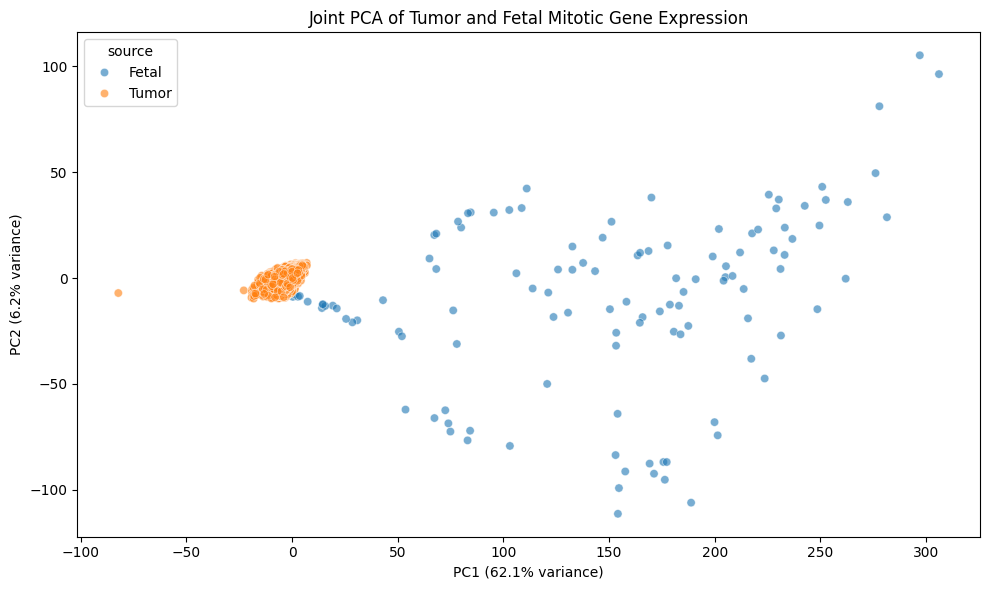

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=joint_pca_df,
    x="PC1",
    y="PC2",
    hue="source",
    alpha=0.6
)

plt.title("Joint PCA of Tumor and Fetal Mitotic Gene Expression")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.savefig("../results/figures/joint_pca.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
# downsample tumors to match fetal size
tumor_sampled = tumor_T.sample(n=119, random_state=42)

# combine again
combined_df = pd.concat([fetal_T, tumor_sampled], axis=0)
labels = combined_df["source"].copy()
combined_df = combined_df.drop(columns=["source"])

print(combined_df.shape)
print(labels.value_counts())

(238, 596)
source
Fetal    119
Tumor    119
Name: count, dtype: int64


In [35]:
X_scaled = StandardScaler().fit_transform(combined_df)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

joint_pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
joint_pca_df["source"] = labels.values

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.6317154  0.07647586]


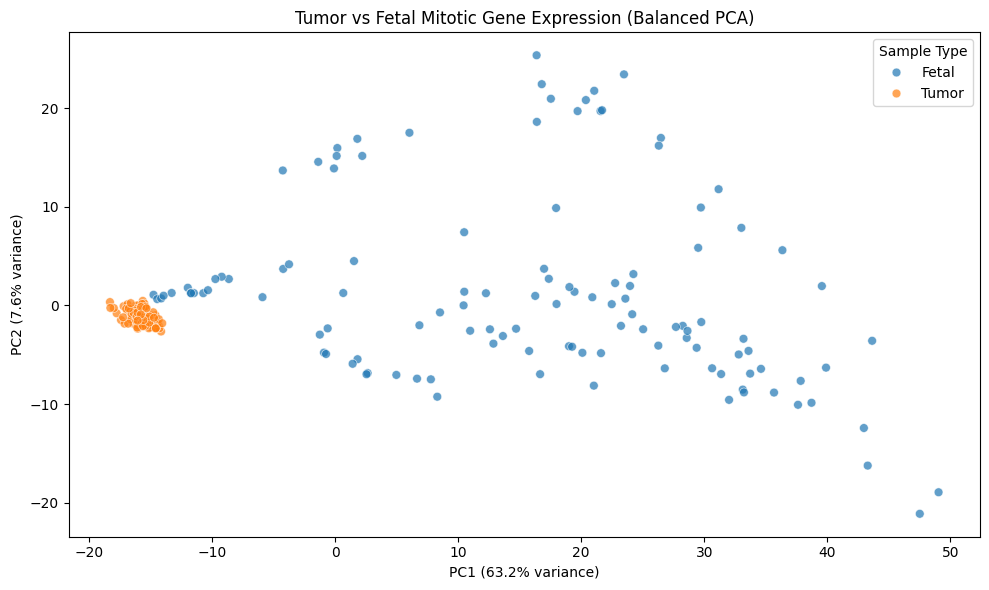

In [36]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=joint_pca_df,
    x="PC1",
    y="PC2",
    hue="source",
    alpha=0.7,
    s=40
)

plt.title("Tumor vs Fetal Mitotic Gene Expression (Balanced PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

plt.legend(title="Sample Type")
plt.tight_layout()

plt.savefig("../results/figures/joint_pca_balanced.png", dpi=300, bbox_inches="tight")

plt.show()

## Interpretation

After balancing sample sizes between tumor and fetal datasets, PCA reveals that tumor samples cluster tightly within a narrow region of mitotic gene expression space, while fetal samples span a much broader range.

This suggests that tumor proliferation programs may represent a constrained subset of the diverse transcriptional states observed during fetal development, rather than broadly recapitulating fetal gene expression patterns.

In [37]:
import re

fetal_meta = pd.DataFrame({"sample": fetal_aligned.columns})

def parse_fetal_label(label):
    label = str(label)
    
    # split on first comma
    parts = label.split(",", 1)
    stage = parts[0].strip() if len(parts) > 0 else "Unknown"
    tissue = parts[1].strip() if len(parts) > 1 else "Unknown"
    
    return pd.Series({"stage": stage, "tissue": tissue})

fetal_meta[["stage", "tissue"]] = fetal_meta["sample"].apply(parse_fetal_label)

print(fetal_meta.head())
print(fetal_meta["tissue"].value_counts().head(15))

                               sample                    stage     tissue
0   5 week post conception, forebrain   5 week post conception  forebrain
1   7 week post conception, forebrain   7 week post conception  forebrain
2   8 week post conception, forebrain   8 week post conception  forebrain
3   9 week post conception, forebrain   9 week post conception  forebrain
4  10 week post conception, forebrain  10 week post conception  forebrain
tissue
liver        21
forebrain    20
heart        19
testis       19
kidney       17
ovary        12
hindbrain    11
Name: count, dtype: int64


In [38]:
fetal_meta["stage_tissue"] = fetal_meta["stage"] + " | " + fetal_meta["tissue"]

# transpose fetal matrix so rows = samples
fetal_samples_by_gene = fetal_aligned.T.copy()
fetal_samples_by_gene["stage_tissue"] = fetal_meta["stage_tissue"].values

# average samples within each fetal stage-tissue group
fetal_centroids = fetal_samples_by_gene.groupby("stage_tissue").mean().T

print("Fetal centroids shape:", fetal_centroids.shape)
print(fetal_centroids.columns[:10].tolist())

Fetal centroids shape: (596, 119)
['10 week post conception | forebrain', '10 week post conception | heart', '10 week post conception | hindbrain', '10 week post conception | kidney', '10 week post conception | liver', '10 week post conception | ovary', '10 week post conception | testis', '11 week post conception | forebrain', '11 week post conception | heart', '11 week post conception | hindbrain']


In [39]:
tumor_subset = tumor_aligned.sample(n=500, axis=1, random_state=42)

print("Tumor subset shape:", tumor_subset.shape)

Tumor subset shape: (596, 500)


In [40]:
from scipy.spatial.distance import cdist

# make sure genes are in same order
shared_for_dist = tumor_subset.index.intersection(fetal_centroids.index)

tumor_for_dist = tumor_subset.loc[shared_for_dist].T
fetal_for_dist = fetal_centroids.loc[shared_for_dist].T

distance_matrix = cdist(
    tumor_for_dist.values,
    fetal_for_dist.values,
    metric="euclidean"
)

distance_df = pd.DataFrame(
    distance_matrix,
    index=tumor_for_dist.index,
    columns=fetal_for_dist.index
)

print("Distance matrix shape:", distance_df.shape)
distance_df.iloc[:5, :5]

Distance matrix shape: (500, 119)


stage_tissue,10 week post conception | forebrain,10 week post conception | heart,10 week post conception | hindbrain,10 week post conception | kidney,10 week post conception | liver
TCGA-FD-A5BV-01,8263.740685,2123.389629,6394.270143,3091.512891,1408.886296
TCGA-DX-A8BM-01,8252.780553,2113.704949,6383.651903,3082.338475,1402.949930
TCGA-DE-A3KN-01,8264.958247,2126.545715,6392.015550,3094.539011,1420.235841
TCGA-EJ-5519-01,8259.363235,2121.984541,6387.506688,3088.999931,1412.273699
TCGA-BP-4160-01,8262.342777,2124.461651,6390.441455,3092.187419,1415.788748


In [42]:
closest_match = distance_df.idxmin(axis=1).rename("closest_fetal_profile")
closest_distance = distance_df.min(axis=1).rename("distance")

tumor_match_df = pd.concat([closest_match, closest_distance], axis=1).reset_index()
tumor_match_df = tumor_match_df.rename(columns={"index": "tumor_sample"})

tumor_match_df["stage"] = tumor_match_df["closest_fetal_profile"].str.split(" \\| ").str[0]
tumor_match_df["tissue"] = tumor_match_df["closest_fetal_profile"].str.split(" \\| ").str[1]

print(tumor_match_df.head())
print(tumor_match_df["tissue"].value_counts().head(10))

      tumor_sample closest_fetal_profile    distance    stage tissue
0  TCGA-FD-A5BV-01       elderly | liver  257.881865  elderly  liver
1  TCGA-DX-A8BM-01       elderly | liver  254.048714  elderly  liver
2  TCGA-DE-A3KN-01       elderly | liver  251.228862  elderly  liver
3  TCGA-EJ-5519-01       elderly | liver  250.146017  elderly  liver
4  TCGA-BP-4160-01       elderly | liver  252.337961  elderly  liver
tissue
liver    500
Name: count, dtype: int64


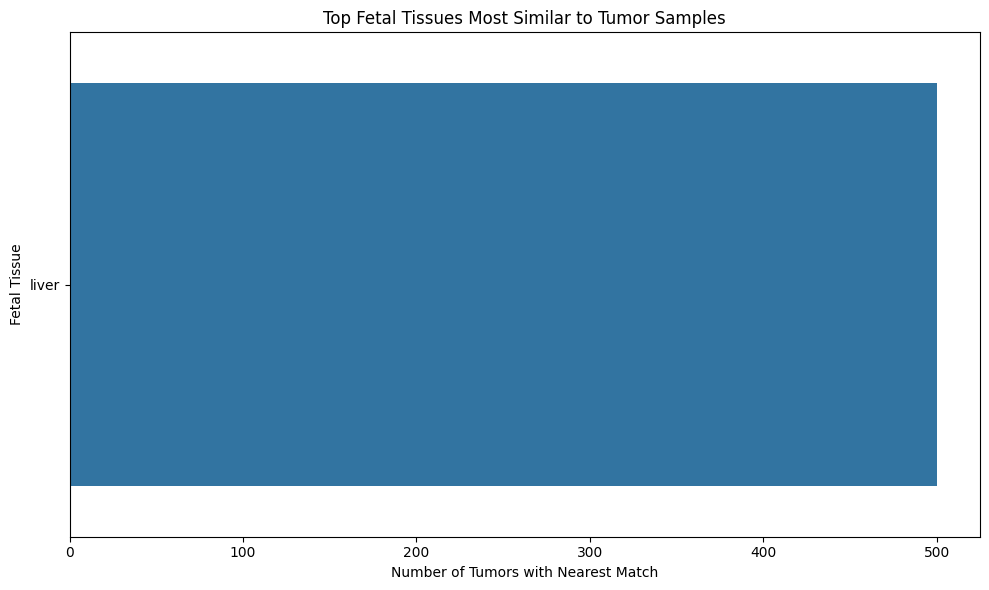

In [44]:
top_tissues = tumor_match_df["tissue"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_tissues.values,
    y=top_tissues.index
)

plt.title("Top Fetal Tissues Most Similar to Tumor Samples")
plt.xlabel("Number of Tumors with Nearest Match")
plt.ylabel("Fetal Tissue")
plt.tight_layout()
plt.savefig("../results/figures/top_fetal_matches.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

# Standardize genes (important)
tumor_scaled = StandardScaler().fit_transform(tumor_for_dist)
fetal_scaled = StandardScaler().fit_transform(fetal_for_dist)

# Use correlation distance instead of Euclidean
distance_matrix = cdist(
    tumor_scaled,
    fetal_scaled,
    metric="correlation"
)

distance_df = pd.DataFrame(
    distance_matrix,
    index=tumor_for_dist.index,
    columns=fetal_for_dist.index
)

print("Distance matrix shape:", distance_df.shape)

Distance matrix shape: (500, 119)


In [46]:
closest_match = distance_df.idxmin(axis=1).rename("closest_fetal_profile")
closest_distance = distance_df.min(axis=1).rename("distance")

tumor_match_df = pd.concat([closest_match, closest_distance], axis=1).reset_index()
tumor_match_df = tumor_match_df.rename(columns={"index": "tumor_sample"})

tumor_match_df["stage"] = tumor_match_df["closest_fetal_profile"].str.split(" \\| ").str[0]
tumor_match_df["tissue"] = tumor_match_df["closest_fetal_profile"].str.split(" \\| ").str[1]

print(tumor_match_df["tissue"].value_counts().head(10))

tissue
kidney       114
testis        99
forebrain     88
liver         83
hindbrain     70
heart         32
ovary         14
Name: count, dtype: int64


In [47]:
tumor_match_df.to_csv("../results/tables/tumor_fetal_matches_corr.csv", index=False)
print("Saved correlation-based matching results.")

Saved correlation-based matching results.


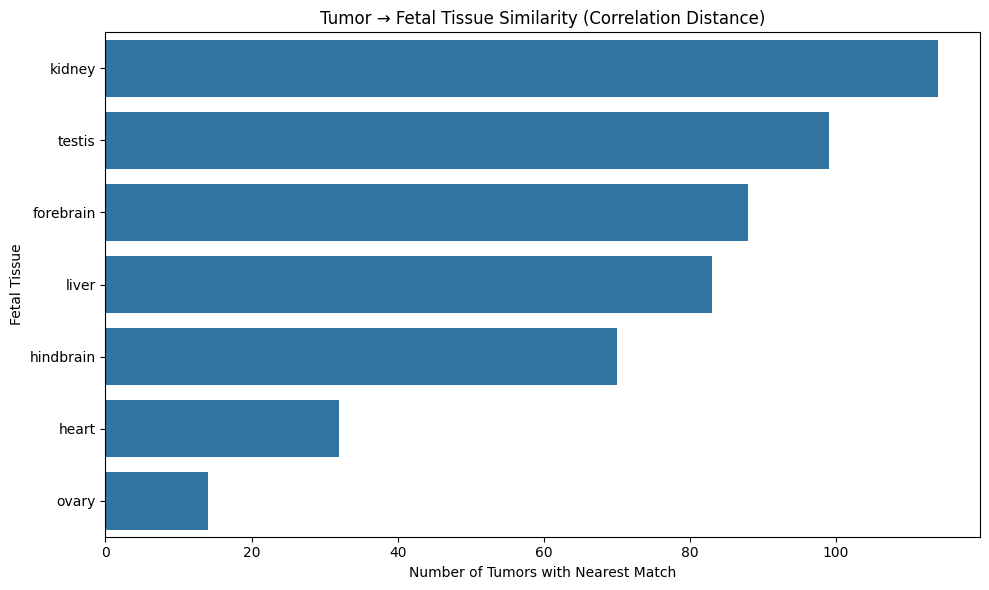

In [48]:
top_tissues = tumor_match_df["tissue"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_tissues.values, y=top_tissues.index)

plt.title("Tumor → Fetal Tissue Similarity (Correlation Distance)")
plt.xlabel("Number of Tumors with Nearest Match")
plt.ylabel("Fetal Tissue")

plt.tight_layout()
plt.savefig("../results/figures/top_fetal_matches_corr.png", dpi=300, bbox_inches="tight")
plt.show()

In [52]:
from sklearn.cluster import KMeans

# Use the SAME matrix you used for matching
X = tumor_for_dist.copy()

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# Cluster tumors
k = 4  # you can adjust later (3–5 is reasonable)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add to dataframe
tumor_cluster_df = tumor_match_df.copy()
tumor_cluster_df["cluster"] = cluster_labels

print(tumor_cluster_df.head())
print(tumor_cluster_df["cluster"].value_counts())

      tumor_sample                closest_fetal_profile  distance  \
0  TCGA-FD-A5BV-01      7 week post conception | kidney  0.666397   
1  TCGA-DX-A8BM-01   5 week post conception | forebrain  0.759351   
2  TCGA-DE-A3KN-01                      infant | testis  0.442527   
3  TCGA-EJ-5519-01  11 week post conception | hindbrain  0.574606   
4  TCGA-BP-4160-01      16 week post conception | heart  0.524920   

                     stage     tissue  cluster  
0   7 week post conception     kidney        0  
1   5 week post conception  forebrain        2  
2                   infant     testis        1  
3  11 week post conception  hindbrain        1  
4  16 week post conception      heart        1  
cluster
2    165
1    152
0    138
3     45
Name: count, dtype: int64


In [53]:
cluster_tissue_counts = (
    tumor_cluster_df
    .groupby("cluster")["tissue"]
    .value_counts()
    .rename("count")
    .reset_index()
)

cluster_tissue_counts.head(20)

,cluster,tissue,count
0,0,liver,52
1,0,kidney,26
2,0,forebrain,25
3,0,testis,14
4,0,heart,10
5,0,hindbrain,7
6,0,ovary,4
7,1,testis,72
8,1,hindbrain,35
9,1,kidney,27


In [54]:
cluster_tissue_props = (
    tumor_cluster_df
    .groupby("cluster")["tissue"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

cluster_tissue_props.head(20)

,cluster,tissue,proportion
0,0,liver,0.376812
1,0,kidney,0.188406
2,0,forebrain,0.181159
3,0,testis,0.101449
4,0,heart,0.072464
5,0,hindbrain,0.050725
6,0,ovary,0.028986
7,1,testis,0.473684
8,1,hindbrain,0.230263
9,1,kidney,0.177632


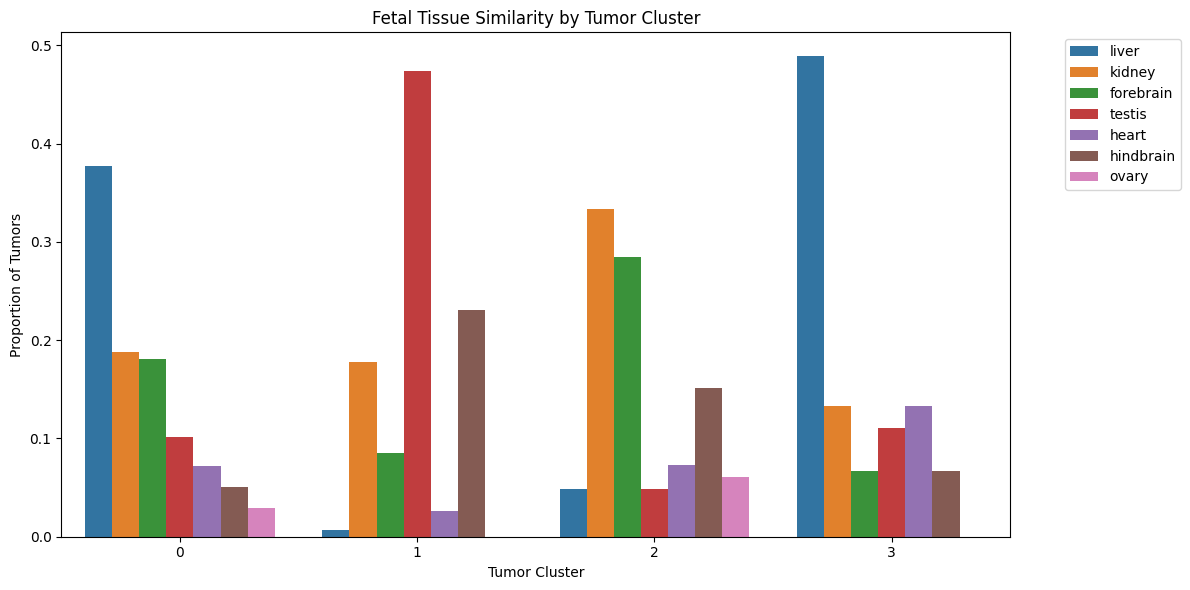

In [55]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=cluster_tissue_props,
    x="cluster",
    y="proportion",
    hue="tissue"
)

plt.title("Fetal Tissue Similarity by Tumor Cluster")
plt.xlabel("Tumor Cluster")
plt.ylabel("Proportion of Tumors")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("../results/figures/cluster_fetal_similarity.png", dpi=300, bbox_inches="tight")
plt.show()